# ML-CUP25 — Ensemble OOF

Questo notebook combina KNN e SVR con la rete PyTorch selezionata in `cup_NN_manual`. LinearSVR resta commentato perché nella prova iniziale ha ricevuto peso zero.

La procedura evita leakage: genera predizioni **out-of-fold (OOF)** con gli stessi fold per tutti i modelli, ottimizza pesi non negativi con somma pari a 1 rispetto alla MEE, riaddestra i modelli sull'intero training set e produce le predizioni per il test set ufficiale.

In [1]:
from pathlib import Path
from functools import partial
import copy
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.optimize import minimize
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR, SVR

import cup_common as cc
import cross_common as cr
import nn_common as nnc

warnings.filterwarnings("ignore", category=ConvergenceWarning)
SEED = 42
N_SPLITS = 5
torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Caricamento dei dati

In [2]:
df_train, df_test = cc.load_set()
X_train, y_train = cc.prepare_dataset(df_train)
X_test, _ = cc.prepare_dataset(df_test)
test_ids = df_test["id"].to_numpy()

assert len(X_train) == len(y_train)
assert X_train.shape[1] == X_test.shape[1]
print(f"Training: X={X_train.shape}, y={y_train.shape}")
print(f"Test:     X={X_test.shape}")

Training: X=(500, 12), y=(500, 4)
Test:     X=(1000, 12)


## 2. Modelli base

Le configurazioni riprendono i migliori parametri trovati nei notebook esistenti. Ogni scaler è incluso nella pipeline e viene quindi stimato soltanto sul training fold.

In [3]:
models = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=3, weights="uniform", p=2)),
    ]),
    "SVR_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MultiOutputRegressor(
            SVR(kernel="rbf", C=30, gamma=3, epsilon=0.1)
        )),
    ]),
    # "LinearSVR": Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("model", MultiOutputRegressor(
    #         LinearSVR(C=0.01, dual=False, loss="squared_epsilon_insensitive",
    #                   max_iter=20_000, random_state=SEED)
    #     )),
    # ]),
}

# Configurazione selezionata in cup_NN_manual.ipynb
NN_CONFIG = {
    "hidden_layers": [128, 64],
    "activation": "gelu",
    "epochs": 1_000,
    "batch_size": 16,
    "learning_rate": 0.008206725313798213,
    "weight_decay": 1.6183611167820987e-05,
}

def make_nn(seed=SEED):
    torch.manual_seed(seed)
    net = nnc.build_nn_net(
        X_train.shape[1], y_train.shape[1],
        NN_CONFIG["hidden_layers"], NN_CONFIG["activation"],
    )
    return nnc.build_nn_model(net, nnc.regression_adapter())

def nn_train_params():
    return {
        "epochs": NN_CONFIG["epochs"],
        "batch_size": NN_CONFIG["batch_size"],
        "optimizer_template": partial(
            torch.optim.AdamW, lr=NN_CONFIG["learning_rate"],
            weight_decay=NN_CONFIG["weight_decay"], betas=(0.95, 0.999),
        ),
        "loss_function": nnc.MEELoss(),
        "scheduler_template": partial(
            torch.optim.lr_scheduler.ReduceLROnPlateau, mode="min",
            threshold_mode="abs", factor=0.5, patience=10, threshold=1e-2,
        ),
        "early_stopping_strategy": nnc.EarlyStoppingStrategy(patience=50, min_delta=1e-2),
        "additional_metrics": {},
        "silence_output": True,
    }

print("Modelli:", [*models, "NN"])

Modelli: ['KNN', 'SVR_RBF', 'NN']


## 3. Predizioni out-of-fold

In [4]:
def mee(y_true, y_pred):
    """Mean Euclidean Error tra vettori target."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.linalg.norm(y_true - y_pred, axis=1)))

cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
all_model_names = [*models, "NN"]
oof_predictions = {
    name: np.zeros_like(y_train, dtype=float) for name in all_model_names
}
fold_scores = {name: [] for name in all_model_names}
nn_training_losses_at_best = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train), start=1):
    X_tr = X_train.iloc[train_idx]
    X_vl = X_train.iloc[val_idx]
    y_tr = y_train[train_idx]
    y_vl = y_train[val_idx]

    print(f"Fold {fold}/{N_SPLITS}")
    for name, template in models.items():
        model = clone(template)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_vl)
        oof_predictions[name][val_idx] = pred
        score = mee(y_vl, pred)
        fold_scores[name].append(score)
        print(f"  {name:10s} MEE={score:.4f}")

    # NN: nuova inizializzazione e scaler stimato soltanto sul training fold
    nn_model = make_nn(seed=SEED + fold)
    nn_scaler = StandardScaler()
    nn_result = nnc.train(
        nn_model,
        nnc.ManualSplitStrategy(
            nnc.FeatureTargetSet(X_tr, y_tr),
            nnc.FeatureTargetSet(X_vl, y_vl),
            scaler=nn_scaler,
        ),
        **nn_train_params(),
    )
    nn_pred = nn_model.predict(pd.DataFrame(nn_scaler.transform(X_vl), columns=X_vl.columns))[0]
    nn_pred = nn_pred.detach().cpu().numpy()
    oof_predictions["NN"][val_idx] = nn_pred
    nn_score = mee(y_vl, nn_pred)
    fold_scores["NN"].append(nn_score)
    best_idx = max(0, nn_result.best_epoch - 1)
    nn_training_losses_at_best.append(nn_result.epochs_tr_loss[best_idx])
    print(f"  {'NN':10s} MEE={nn_score:.4f} (best epoch={nn_result.best_epoch})")

Fold 1/5
  KNN        MEE=15.0456
  SVR_RBF    MEE=16.3076


/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  NN         MEE=20.8963 (best epoch=43)
Fold 2/5
  KNN        MEE=16.1172
  SVR_RBF    MEE=16.9211


/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  NN         MEE=19.3068 (best epoch=63)
Fold 3/5
  KNN        MEE=15.6121
  SVR_RBF    MEE=16.3351


/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  NN         MEE=20.5293 (best epoch=89)
Fold 4/5
  KNN        MEE=16.5264
  SVR_RBF    MEE=18.1514


/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  NN         MEE=21.5731 (best epoch=69)
Fold 5/5
  KNN        MEE=15.4174
  SVR_RBF    MEE=16.6925
  NN         MEE=20.4857 (best epoch=36)


/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,OOF MEE
KNN,15.743738
SVR_RBF,16.881533
NN,20.558234


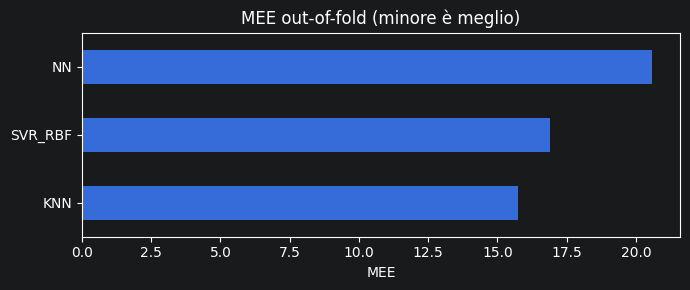

In [5]:
oof_scores = pd.Series(
    {name: mee(y_train, pred) for name, pred in oof_predictions.items()},
    name="OOF MEE",
).sort_values()
display(oof_scores.to_frame())

ax = oof_scores.plot.barh(figsize=(7, 3), title="MEE out-of-fold (minore è meglio)")
ax.set_xlabel("MEE")
plt.tight_layout()
plt.show()

## 4. Ottimizzazione dei pesi

I pesi sono vincolati a essere non negativi e ad avere somma 1. L'ottimizzazione usa esclusivamente le predizioni OOF, mai il test ufficiale.

In [6]:
model_names = list(oof_predictions)
oof_stack = np.stack([oof_predictions[name] for name in model_names], axis=0)

def blend_predictions(stack, weights):
    return np.tensordot(weights, stack, axes=(0, 0))

def objective(weights):
    return mee(y_train, blend_predictions(oof_stack, weights))

initial_weights = np.full(len(model_names), 1 / len(model_names))
result = minimize(
    objective,
    x0=initial_weights,
    method="SLSQP",
    bounds=[(0.0, 1.0)] * len(model_names),
    constraints={"type": "eq", "fun": lambda w: w.sum() - 1.0},
    options={"maxiter": 2_000, "ftol": 1e-10},
)

if not result.success:
    raise RuntimeError(f"Ottimizzazione fallita: {result.message}")

weights = result.x / result.x.sum()
weights_table = pd.Series(weights, index=model_names, name="Peso").sort_values(ascending=False)
oof_ensemble = blend_predictions(oof_stack, weights)
display(weights_table.to_frame())
print(f"MEE OOF ensemble: {mee(y_train, oof_ensemble):.4f}")
print(f"Miglior singolo:  {oof_scores.min():.4f} ({oof_scores.idxmin()})")

,Peso
KNN,0.703742
SVR_RBF,0.269390
NN,0.026868


MEE OOF ensemble: 15.4393
Miglior singolo:  15.7437 (KNN)


### Correlazione degli errori OOF

In [7]:
flat_errors = {
    name: (y_train - pred).ravel() for name, pred in oof_predictions.items()
}
error_correlation = pd.DataFrame(flat_errors).corr()
display(error_correlation.round(3))

,KNN,SVR_RBF,NN
KNN,1.000,0.825,0.654
SVR_RBF,0.825,1.000,0.742
NN,0.654,0.742,1.000


## 5. Addestramento finale e predizione

Ogni modello viene riaddestrato su tutti i 500 esempi. Le predizioni vengono poi combinate con i pesi OOF.

In [8]:
fitted_models = {}
test_predictions = {}

for name, template in models.items():
    print(f"Fit finale: {name}")
    fitted_models[name] = clone(template).fit(X_train, y_train)
    test_predictions[name] = fitted_models[name].predict(X_test)

# Retraining finale NN secondo il criterio usato in cup_NN_manual:
# raggiungere sul training completo la loss TR media osservata ai best epoch OOF.
nn_target_training_loss = float(np.mean(nn_training_losses_at_best))
nn_final_scaler = StandardScaler().fit(X_train)
X_train_nn = pd.DataFrame(nn_final_scaler.transform(X_train), columns=X_train.columns)
X_test_nn = pd.DataFrame(nn_final_scaler.transform(X_test), columns=X_test.columns)
nn_final = make_nn(seed=SEED)
nn_final_params = nn_train_params()
nn_final_params.pop("scheduler_template")
nn_final_params.pop("early_stopping_strategy")
nn_final_params["train_control"] = nn_target_training_loss
nnc.train(
    nn_final,
    nnc.FullTrainingStrategy(nnc.FeatureTargetSet(X_train_nn, y_train)),
    **nn_final_params,
)
fitted_models["NN"] = nn_final
test_predictions["NN"] = nn_final.predict(X_test_nn)[0].detach().cpu().numpy()

test_stack = np.stack([test_predictions[name] for name in model_names], axis=0)
y_pred_ensemble = blend_predictions(test_stack, weights)
assert y_pred_ensemble.shape == (len(X_test), 4)
y_pred_ensemble[:5]

Fit finale: KNN
Fit finale: SVR_RBF


array([[ -2.58539176,  -1.79224087,   6.34891033,  -6.19799629],
       [ -9.62875747,  -3.42058734, -47.56040345,   6.29338227],
       [ -2.30190022,  -2.80426568,  -3.63000027,   6.019732  ],
       [ -5.98506065,  11.5592209 , -29.52827183,   7.66460285],
       [  3.19917933,  -8.53797127, -22.39796259,  21.05522813]])

## 6. Salvataggio

Vengono prodotti:
- `pred_cup_ensemble.npy`: matrice NumPy `(1000, 4)`;
- `pred_cup_ensemble.csv`: ID e quattro target, utile per ispezione;
- `ensemble_weights.csv`: pesi selezionati.

In [9]:
output_dir = Path("ensemble_outputs")
output_dir.mkdir(exist_ok=True)

np.save(output_dir / "pred_cup_ensemble.npy", y_pred_ensemble)

submission = pd.DataFrame(y_pred_ensemble, columns=cc.output_columns)
submission.insert(0, "id", test_ids)
submission.to_csv(output_dir / "pred_cup_ensemble.csv", index=False)
weights_table.rename_axis("model").to_csv(output_dir / "ensemble_weights.csv")

display(submission.head())
print(f"File salvati in: {output_dir.resolve()}")

,id,t1,t2,t3,t4
0,1,-2.585392,-1.792241,6.348910,-6.197996
1,2,-9.628757,-3.420587,-47.560403,6.293382
2,3,-2.301900,-2.804266,-3.630000,6.019732
3,4,-5.985061,11.559221,-29.528272,7.664603
4,5,3.199179,-8.537971,-22.397963,21.055228


File salvati in: /Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/ensemble_outputs


## Note

- Se l'ensemble OOF non supera il miglior modello singolo, usa il miglior modello singolo: l'ensemble non è automaticamente migliore.
- La rete neurale usa la configurazione di `cup_NN_manual.ipynb` e viene reinizializzata in ogni fold.
- Per una stima più rigorosa delle prestazioni dell'intera procedura di scelta dei pesi servirebbe una cross-validation esterna; questa versione è pensata per costruire l'ensemble finale in modo semplice e riproducibile.